In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
! cp -r /kaggle/input/chest-xray-pneumonia /content/chest-xray

In [6]:
!ls /content/chest-xray/chest_xray

chest_xray  __MACOSX  test  train  val


In [7]:
import os
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
train_path = "/content/chest-xray/chest_xray/train"
val_path = "/content/chest-xray/chest_xray/val"
test_path = "/content/chest-xray/chest_xray/test"

## Split

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    batch_size=32,
    image_size=(224, 224),
    seed = 42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    batch_size=32,
    image_size=(224, 224),
    seed = 42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(224, 224),
    seed = 42
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [23]:
class_names = train_ds.class_names
print("Number of classes:", len(class_names))
print("Class names:", class_names)

Number of classes: 2
Class names: ['NORMAL', 'PNEUMONIA']


## Autotune

In [24]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
val_ds = val_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

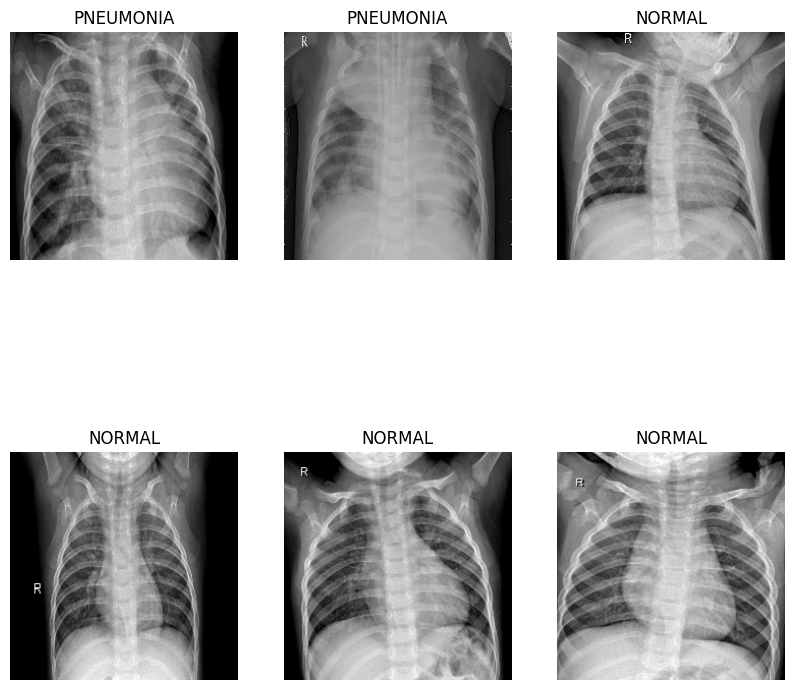

In [30]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()